In [1]:
import matplotlib.pyplot as plt
import json
import glob
import os
import pandas as pd
import seaborn as sns

In [3]:
LANGUAGES = ["PB NATIVO", "ESPANHOL", "FRANCÊS", "GALEGO", "INGLÊS", "MANDARIM", "RUSSO", "ÁRABE"]
N_LANGUAGES = len(LANGUAGES) 


TASKS = ["CAPACITAR", "COMPARTILHAR", "EXPLICAR", "EXPLORAR", "FAZER", "RECOMENDAR", "RECRIAR", "RELATAR"]
N_TASKS = len(TASKS)

typeLM = {
    "causalLM": {
        "files": glob.glob(f"./causalLM/*.json"),
        "metrics": ["avg_tokens_per_word", "avg_ppl", "avg_bpb"]
    },
    "maskedLM": {
        "files": glob.glob(f"./maskedLM/*.json"),
        "metrics": ["avg_tokens_per_word", "avg_pseudo_ppl", "avg_bpb"]
    },
}

typeLM

{'causalLM': {'files': ['./causalLM/Tucano.json',
   './causalLM/Qwen.json',
   './causalLM/Gemma.json',
   './causalLM/Gervasio.json'],
  'metrics': ['avg_tokens_per_word', 'avg_ppl', 'avg_bpb']},
 'maskedLM': {'files': ['./maskedLM/Serafim335m.json',
   './maskedLM/BERTimbauLarge.json',
   './maskedLM/Albertina100m.json',
   './maskedLM/BERTimbau.json',
   './maskedLM/Albertina900m.json'],
  'metrics': ['avg_tokens_per_word', 'avg_pseudo_ppl', 'avg_bpb']}}

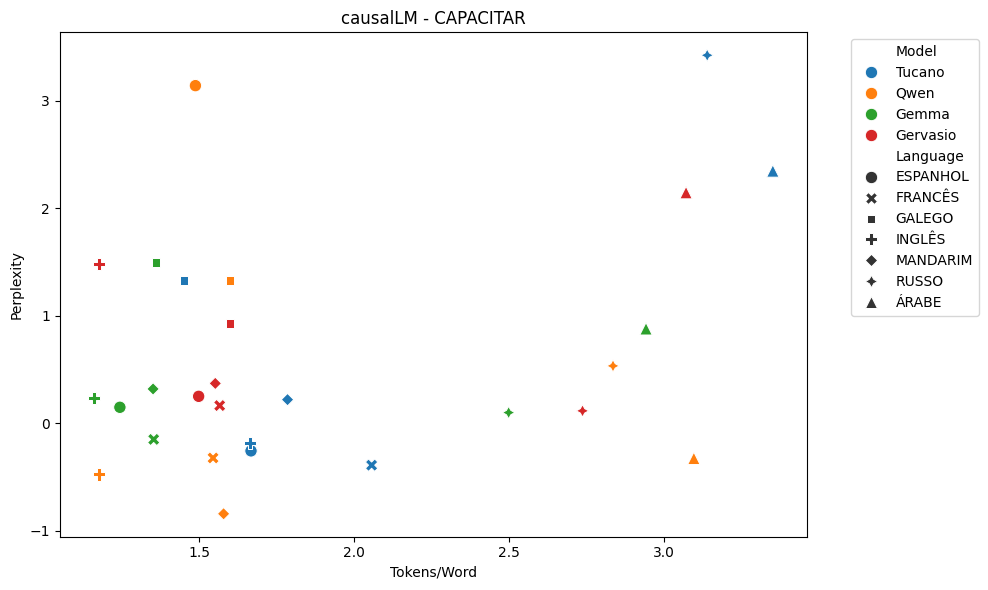

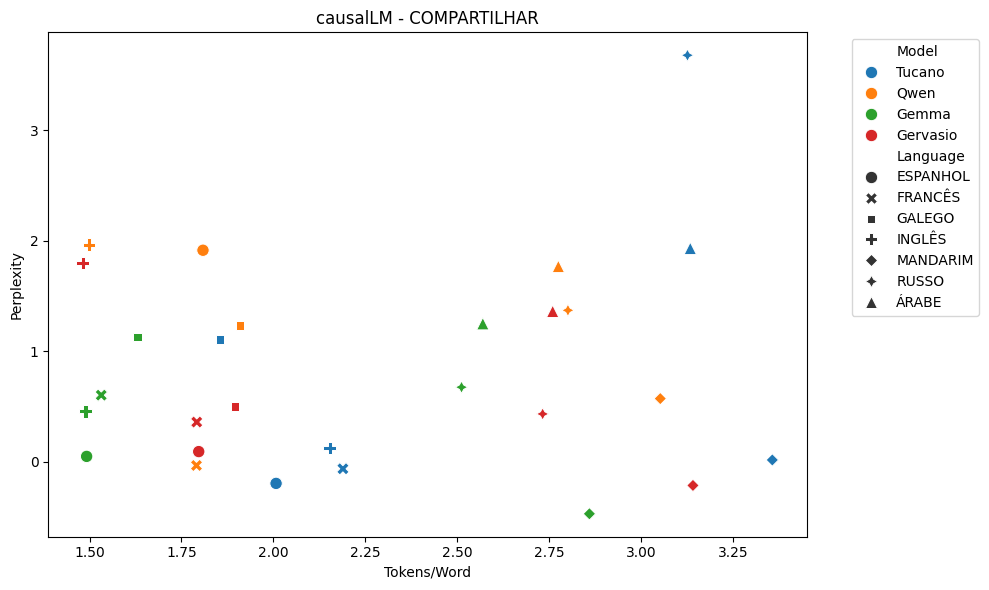

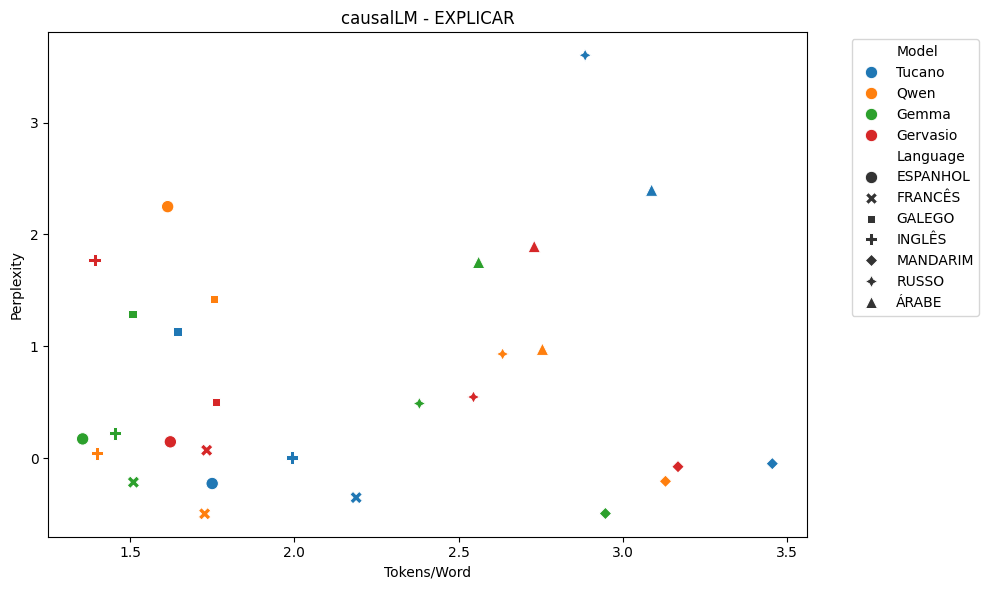

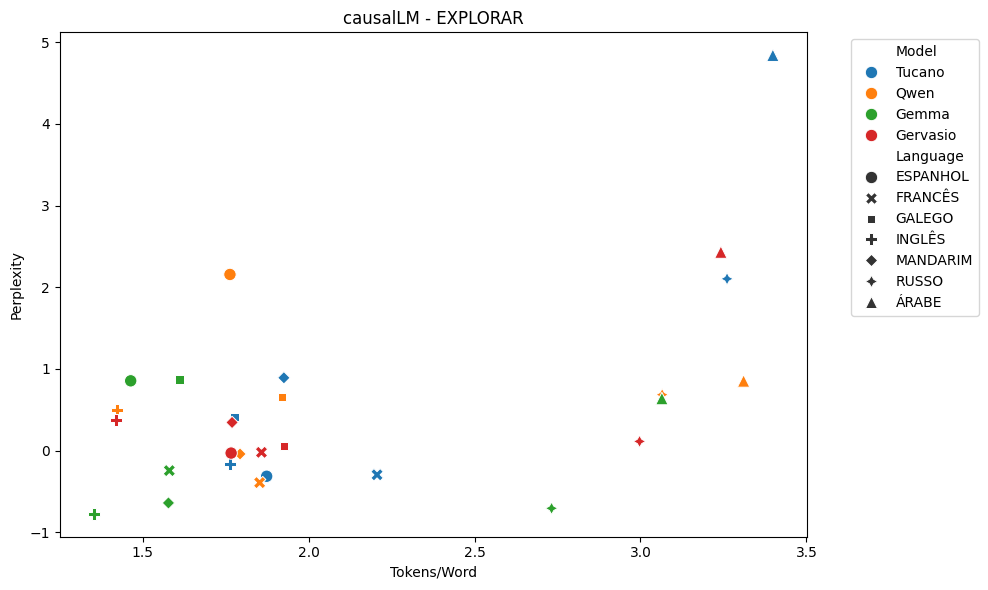

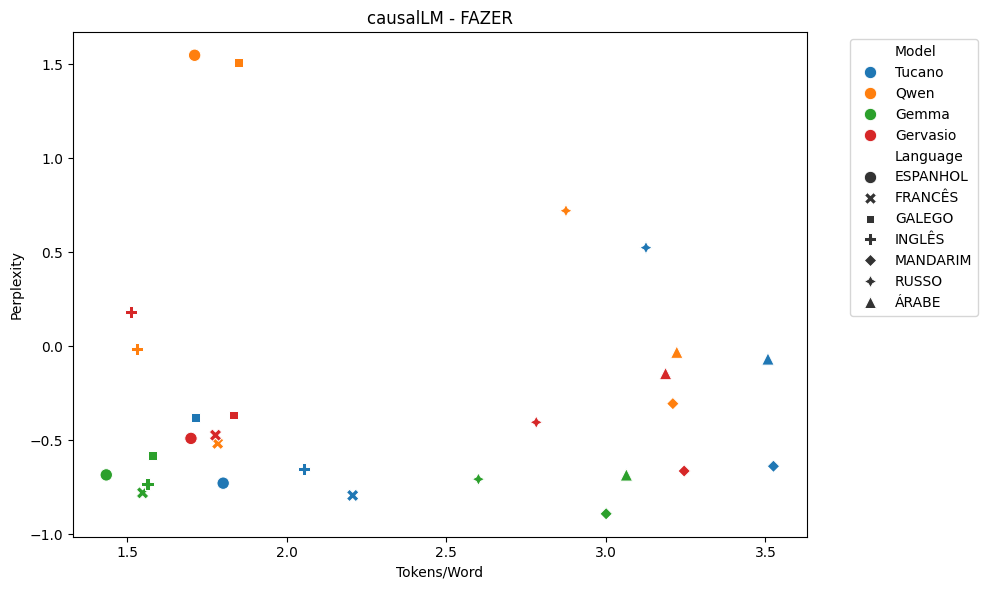

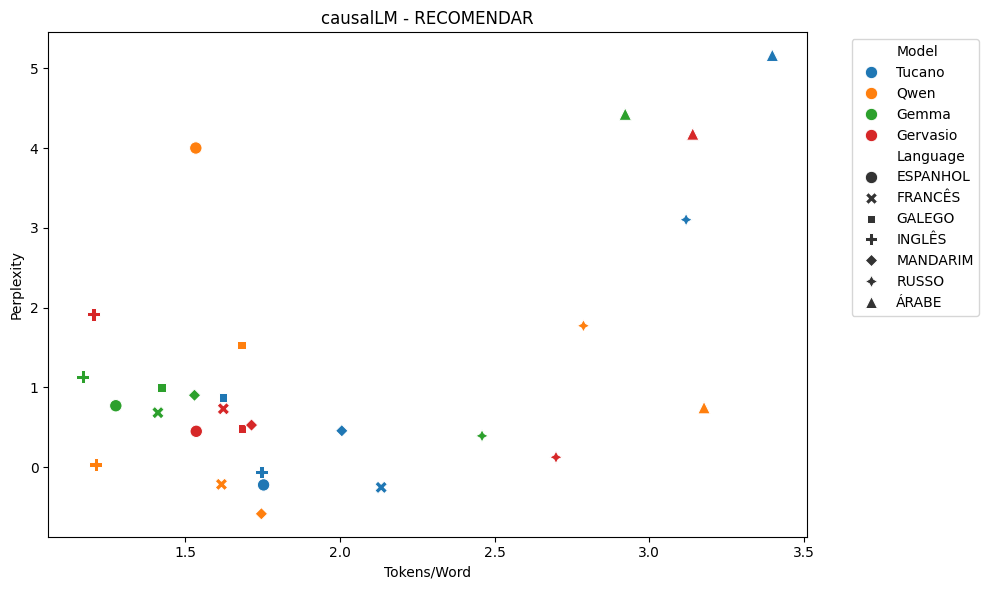

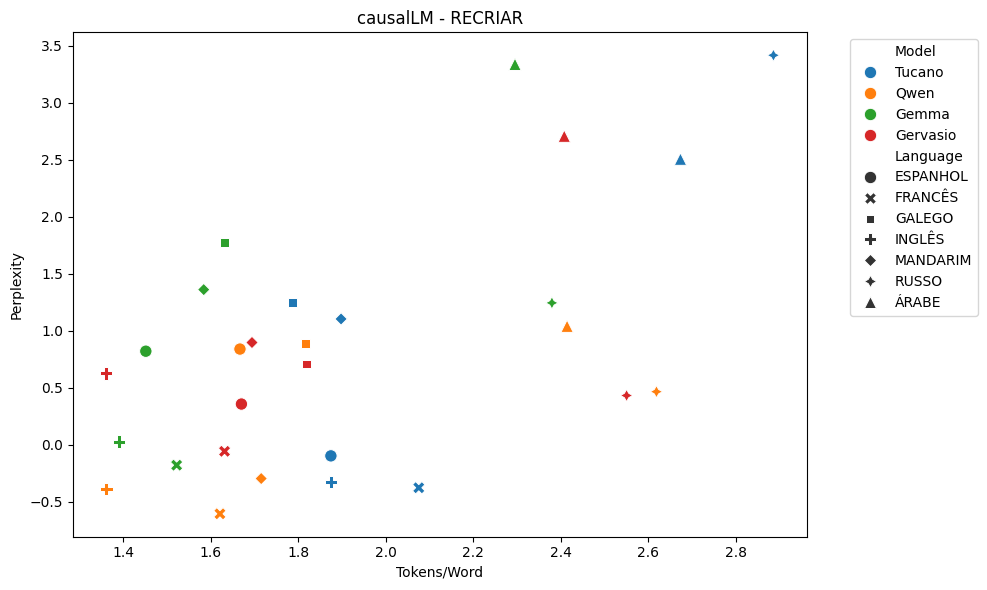

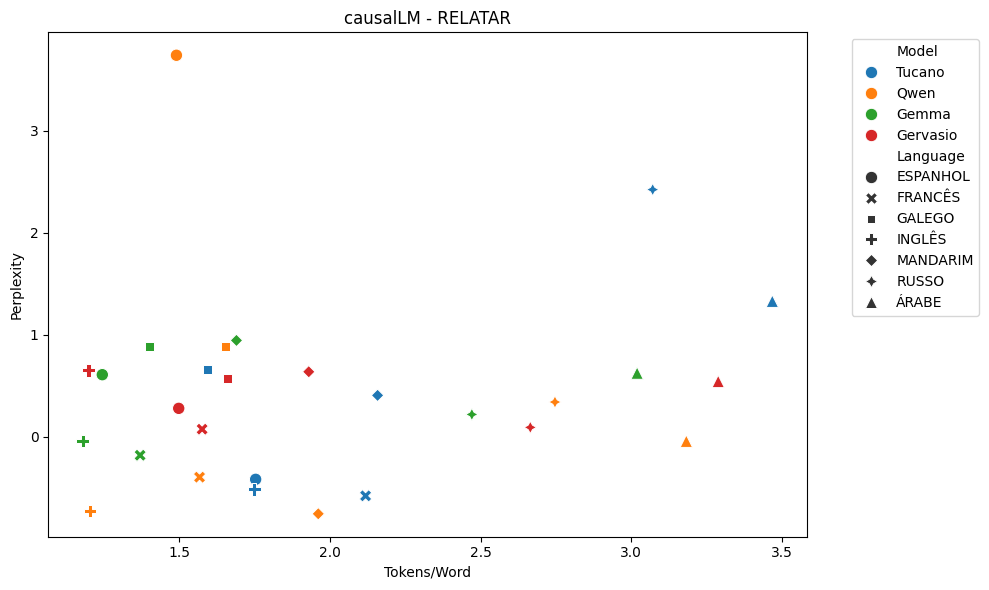

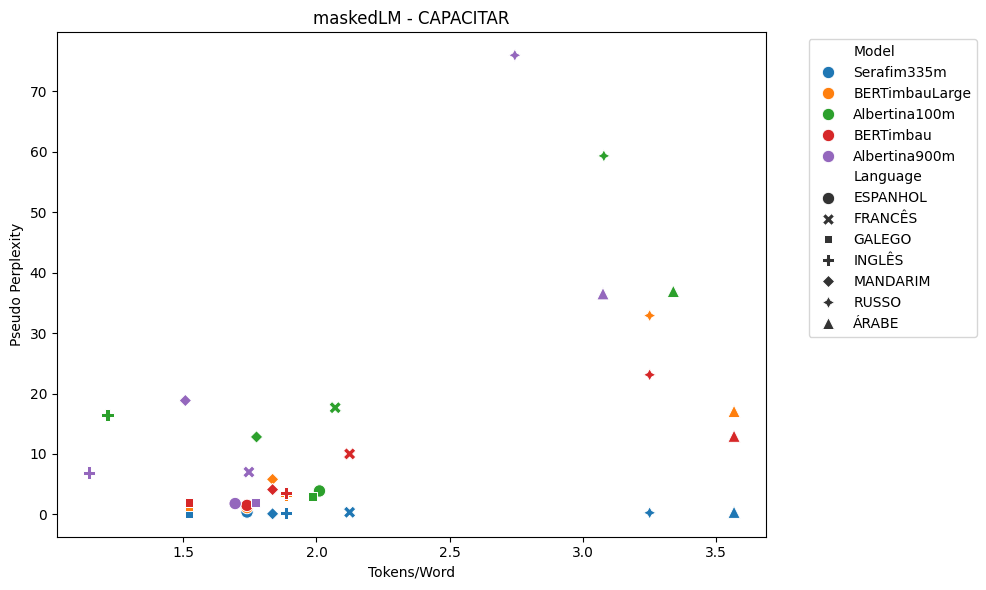

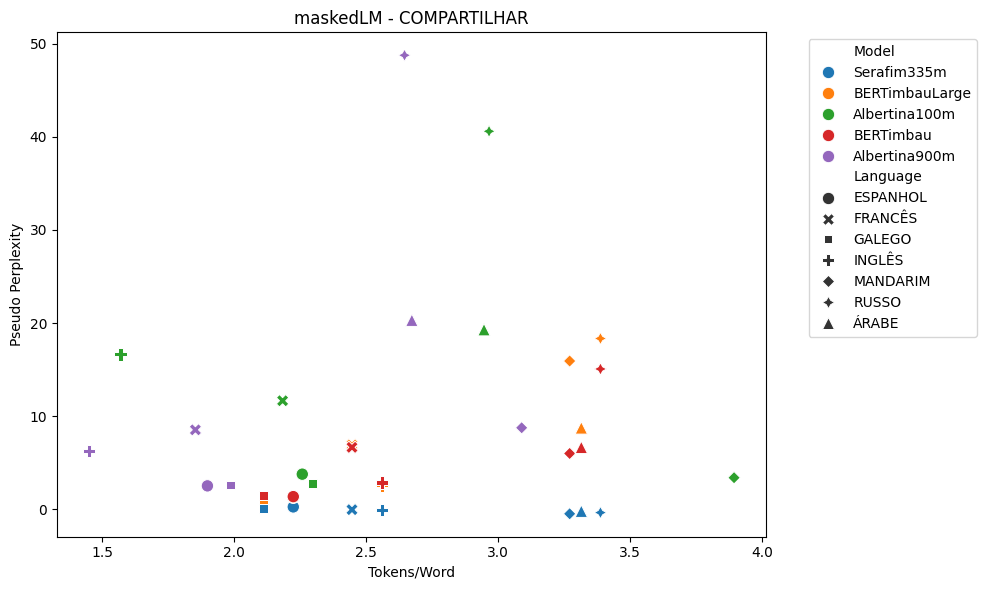

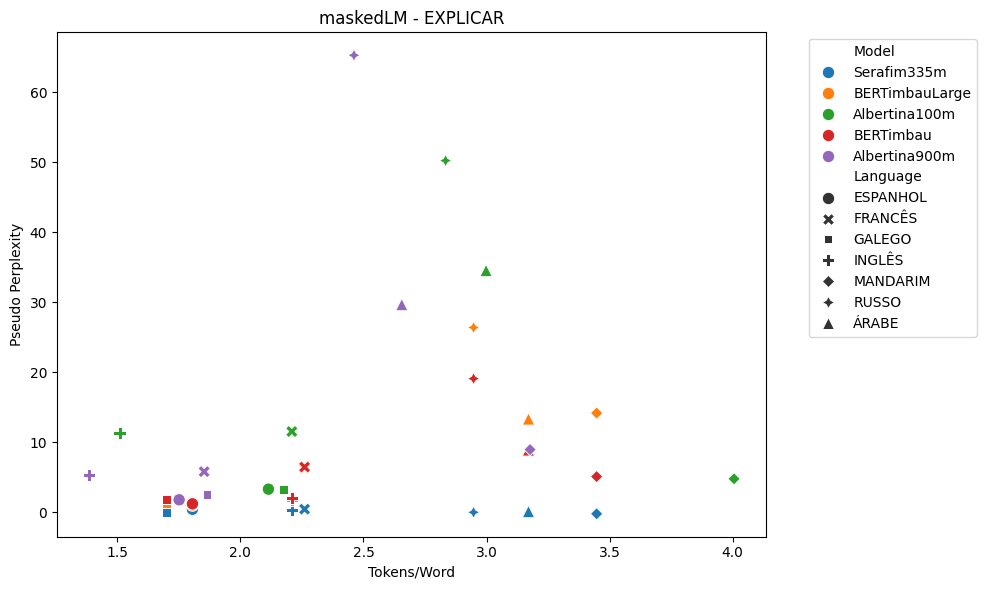

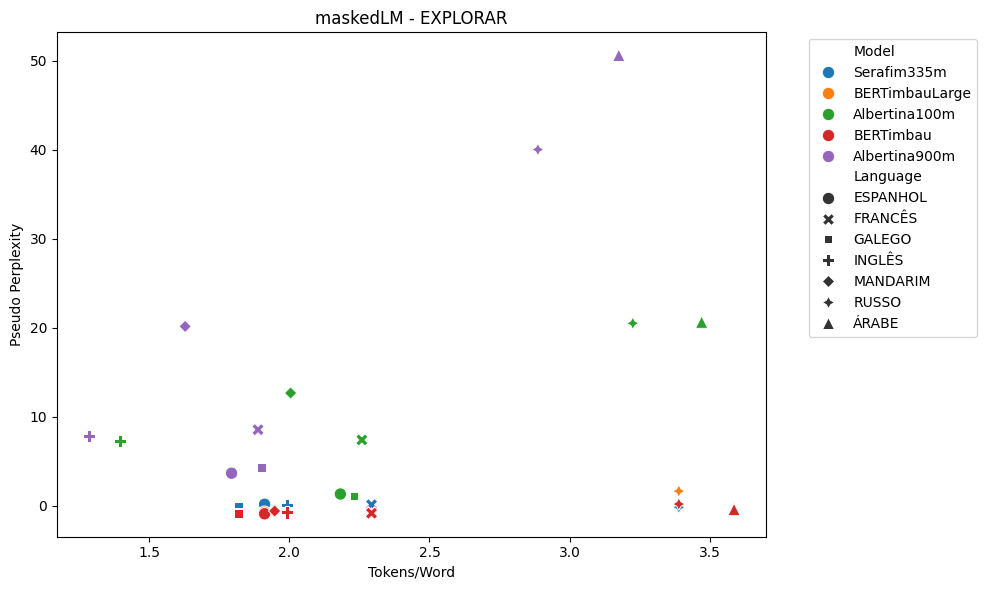

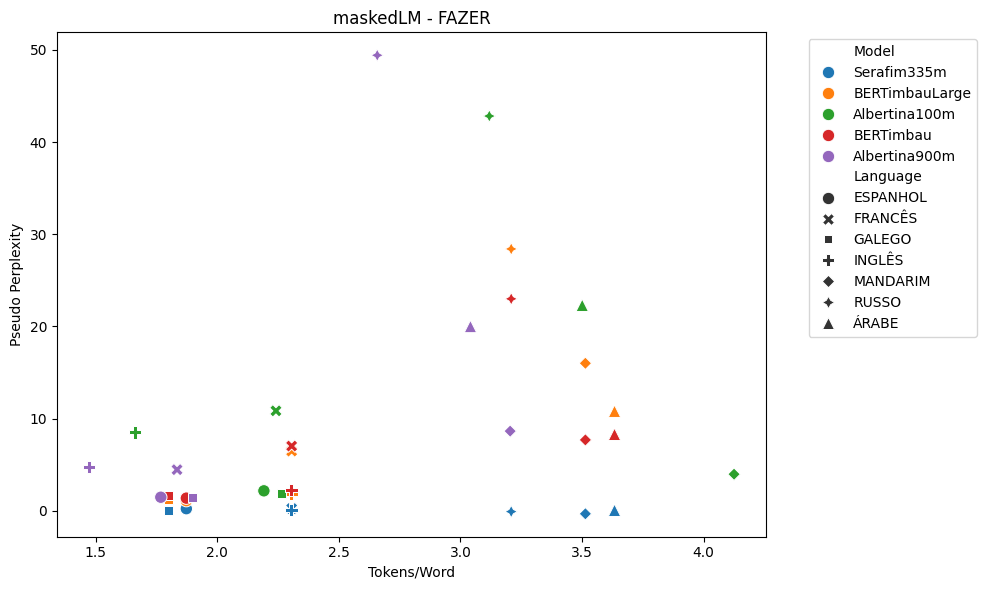

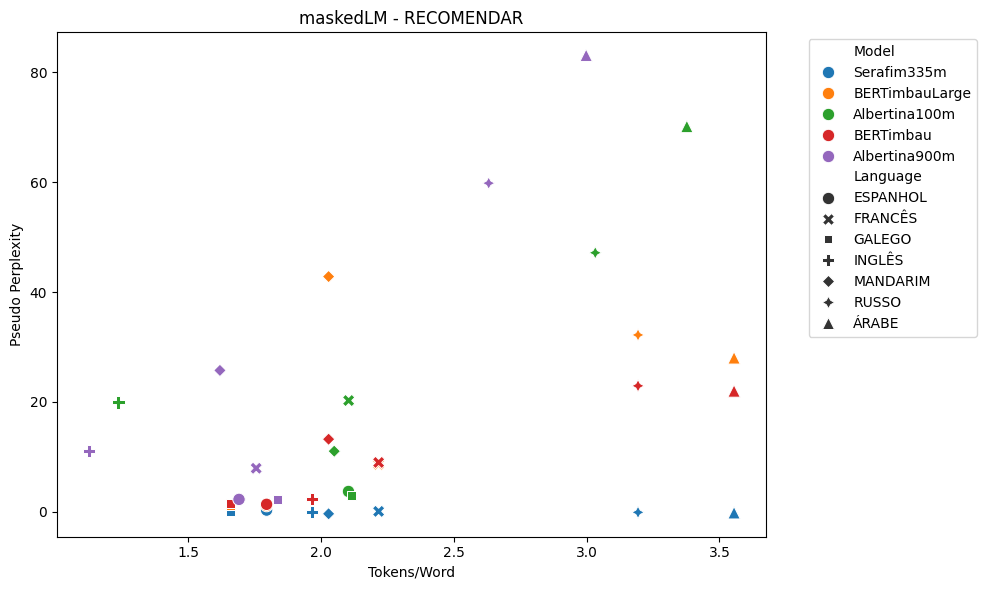

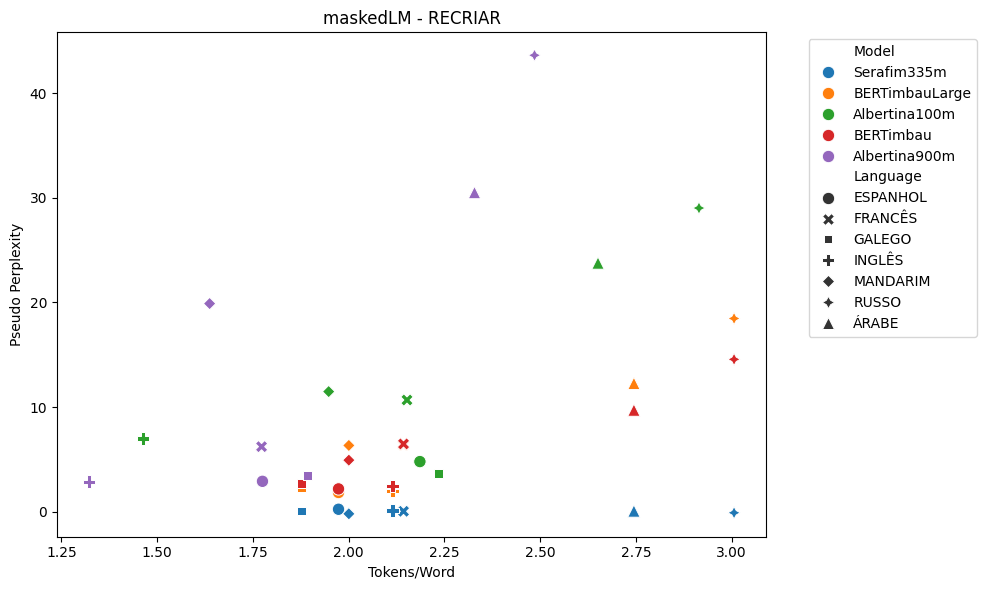

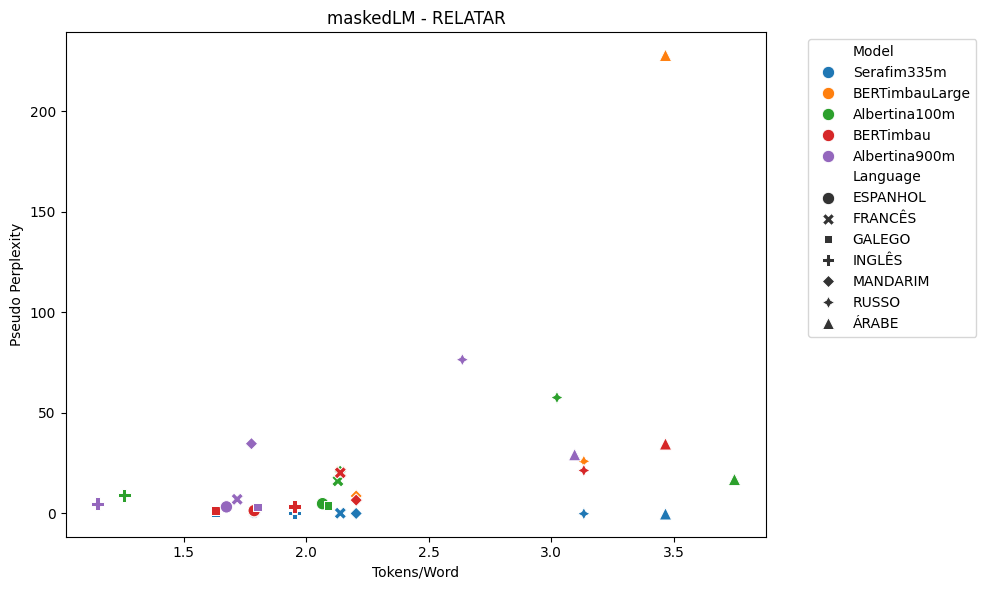

In [6]:
for lm_type, lm_info in typeLM.items():
    files_data = {}

    ppl_metric = "avg_ppl"
    ppl_key = "Perplexity"
    
    if "avg_ppl" not in lm_info["metrics"]:
        ppl_metric = "avg_pseudo_ppl"
        ppl_key = "Pseudo Perplexity"


    files_data = dict()

    for file in lm_info["files"]:

        model_name = os.path.basename(file).replace(".json", "")
        
        with open(file, 'r', encoding='utf-8') as file:
            data = json.load(file)
        
        files_data[model_name] = data

    for task in TASKS:
        chart_data = {
            "Tokens/Word": [],
            ppl_key: [],
            "Model": [],
            "Language": []
        }

        for model, results in files_data.items():
            PT_BR = results[task]["PB NATIVO"][ppl_metric]

            for language in LANGUAGES:
                if language == "PB NATIVO":
                    continue

                ppl = results[task][language][ppl_metric]
                delta = ppl / PT_BR - 1

                tokens_per_word = results[task][language]["avg_tokens_per_word"]

                chart_data["Tokens/Word"].append(tokens_per_word)
                chart_data[ppl_key].append(delta)
                chart_data["Model"].append(model)
                chart_data["Language"].append(language)


        df = pd.DataFrame(chart_data)

        plt.figure(figsize=(10, 6))

        sns.scatterplot(
            data=df,
            x="Tokens/Word",
            y=ppl_key,
            hue="Model",
            style="Language",
            s=80
        )

        plt.legend(
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )

        plt.title(f"{lm_type} - {task}")
        plt.tight_layout()

        # Salvar PDF
        plt.savefig(f"./charts/{lm_type}_{task}.pdf", format="pdf", bbox_inches="tight")

        plt.show()

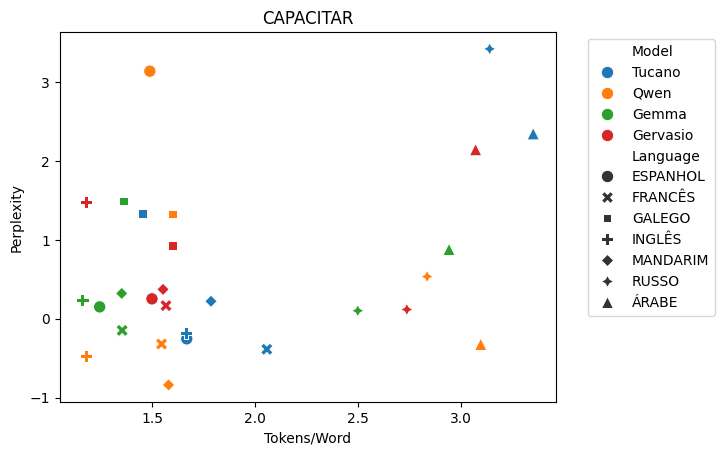

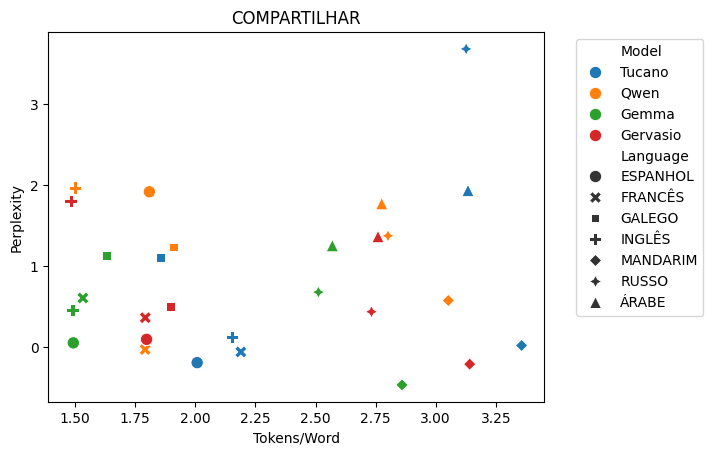

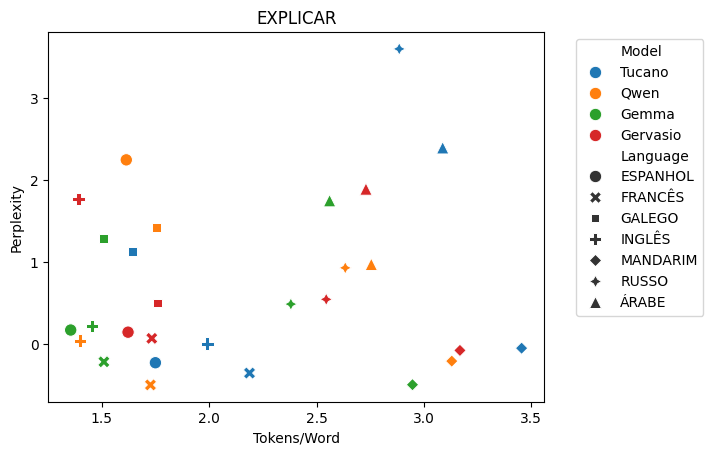

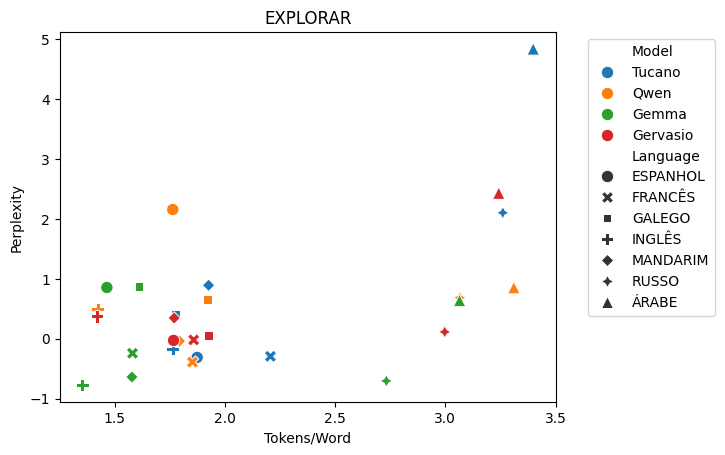

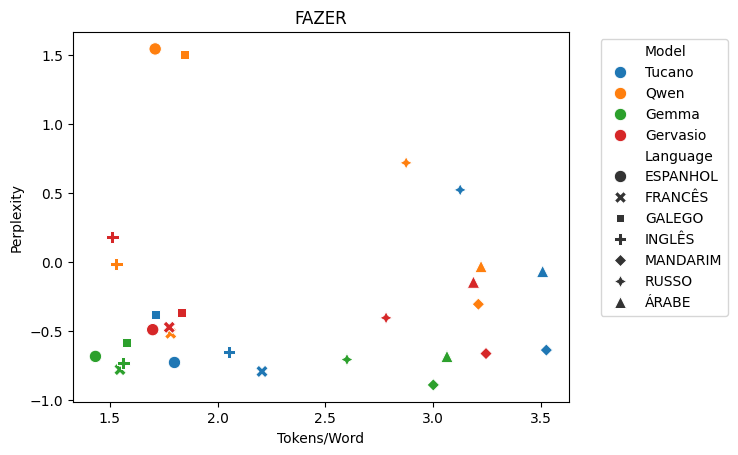

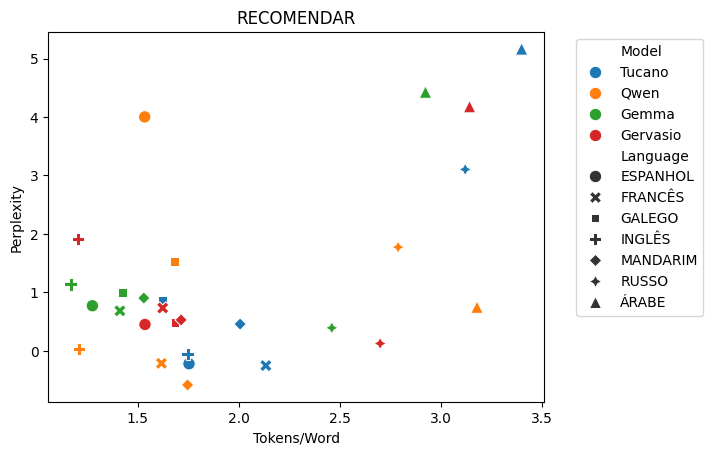

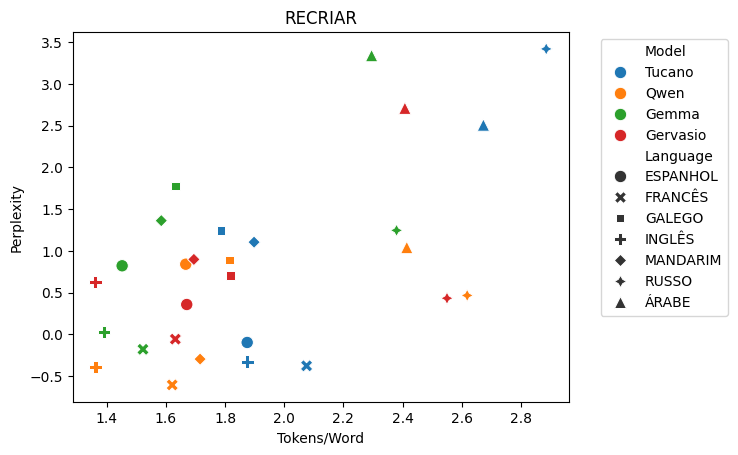

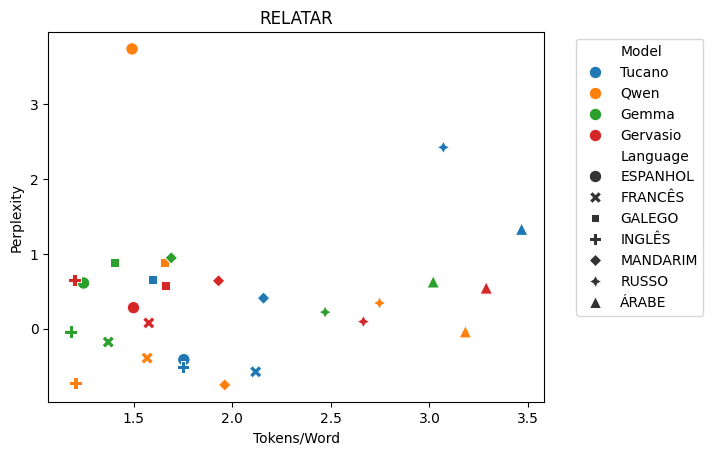

In [ ]:
files_data = dict()

for file in typeLM["causalLM"]["files"]:

    model_name = os.path.basename(file).replace(".json", "")
    
    with open(file, 'r', encoding='utf-8') as file:
        data = json.load(file)
    
    files_data[model_name] = data


for task in TASKS:
    chart_data = {
        "Tokens/Word": [],
        "Perplexity": [],
        "Model": [],
        "Language": []
    }

    for model, results in files_data.items():
        PT_BR = results[task]["PB NATIVO"]["avg_ppl"]

        for language in LANGUAGES:
            if language == "PB NATIVO":
                continue

            ppl = results[task][language]["avg_ppl"]
            delta = ppl/PT_BR - 1

            tokens_per_word = results[task][language]["avg_tokens_per_word"]

            chart_data["Tokens/Word"].append(tokens_per_word)
            chart_data["Perplexity"].append(delta)
            chart_data["Model"].append(model)
            chart_data["Language"].append(language)

    df = pd.DataFrame(chart_data)

    # Create scatter plot with groups separated by color
    sns.scatterplot(data=df, x="Tokens/Word", y="Perplexity", hue="Model", style="Language", s=80)

    # Display the plot
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.title(task)

    # plt.savefig(f'{task}.pdf', format='pdf', bbox_inches="tight")

    
    plt.show()

